In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
from scipy.stats import bootstrap

In [2]:
DP = DP()
all_df, _, _, _ = DP.extract_fits_data('./catalogs/0315_all_test.fits')
dps_df, _, _, _ = DP.extract_fits_data('./catalogs/0315_dps_test.fits')

In [3]:
print(len(all_df))
print(len(dps_df))

57271
25671


In [4]:
dps_df.head(10)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,NII6583_SNR,SII6716_SNR,SII6731_SNR,BPT_1COMP,BPT_2COMP_L,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP,dp_count
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.190807,-78.605568,50.497227,30.429682,...,3.326572,-1.000000,-1.000000,256,256,256,512,0.303909,-0.573267,2
1,39627739380057506,177.058472,-1.984356,0.102379,10.324259,-0.880754,113.683365,-61.165855,41.490192,69.213898,...,5.204332,-1.000000,-1.000000,256,256,256,512,-1.270763,-2.077943,1
2,39627739380058467,177.097977,-1.888290,0.123931,10.402426,1.031611,88.310776,-28.034325,30.202028,51.832150,...,7.630068,4.604237,3.504211,256,256,256,512,0.006628,-0.577312,3
3,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,73.980766,-94.167976,57.098171,51.152435,...,3.775856,-1.000000,-1.000000,256,256,256,512,-0.202920,-1.160233,2
4,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,87.747307,-73.973824,38.576229,50.498489,...,14.727792,8.114503,5.407719,1,1,1,2,0.253700,0.314512,5
5,39627739384252917,177.358017,-1.933391,0.082934,10.019835,-1.504955,55.170998,-69.174751,28.905643,50.764622,...,5.811445,-1.000000,-1.000000,1,1,1,2,-0.464785,-1.482236,2
6,39627739384253125,177.367218,-1.890628,0.082792,9.603887,0.054528,62.536972,-18.696280,21.357780,38.241188,...,25.761667,14.882916,10.351551,1,1,1,2,0.052561,-0.093192,2
7,39627739384253866,177.401154,-1.923410,0.322626,10.556721,1.160900,75.211136,-84.288429,63.610744,50.902027,...,5.241505,-1.000000,-1.000000,1,1,1,2,0.266869,-0.488258,2
8,39627739384254171,177.415359,-1.963895,0.242680,10.280345,0.504521,113.376678,-23.616848,14.704741,78.041893,...,4.209435,-1.000000,-1.000000,256,256,256,512,-0.743167,-1.005256,1
9,39627739384254755,177.441299,-1.894929,0.323152,10.681046,0.655952,89.955185,-90.666977,65.546280,76.824318,...,10.500822,3.489092,-1.000000,256,256,256,512,1.003739,0.110761,2


In [5]:
all_df = all_df[((~all_df['LOGSFR_1COMP'].isna())|(all_df['LOGSFR_1COMP']!=np.inf)) & (all_df['LOGM']!=0)]
dps_df = dps_df[((~dps_df['LOGSFR_2COMP'].isna())|(dps_df['LOGSFR_2COMP']!=np.inf)) & (dps_df['LOGM']!=0)]

In [6]:
all_df.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,Halpha_SNR,NII6583_SNR,SII6716_SNR,SII6731_SNR,BPT_1COMP,BPT_2COMP_L,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP
0,39627739380056197,177.003815,-1.903397,0.224113,10.250154,-0.348563,60.781155,-13.345847,0.001000,60.134190,...,6.263660,-1.000000,-1.000000,-1.000000,256,256,256,512,-1.420273,-1.525873
1,39627739380056420,177.013474,-1.972766,0.102005,9.722919,-0.349153,42.962982,-23.994318,0.001000,32.898586,...,6.106417,-1.000000,-1.000000,-1.000000,256,256,256,512,-1.576572,-2.528599
2,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.190807,-78.605568,50.497227,30.429682,...,8.531772,3.326572,-1.000000,-1.000000,256,256,256,512,0.303909,-0.573267
3,39627739380056768,177.028137,-1.960056,0.102814,10.143390,0.193251,3.580806,-128.504532,43.998024,0.001000,...,23.851063,5.407113,6.336539,4.945838,1,1,1,2,-0.252130,-0.259632
4,39627739380056864,177.032974,-1.909970,0.167324,10.575974,-9.632146,10.120359,-169.964096,85.200417,58.896191,...,5.641017,4.026344,-1.000000,-1.000000,256,256,256,512,-1.324913,-1.684547


In [7]:
print(len(all_df))
print(len(dps_df))

56547
25568


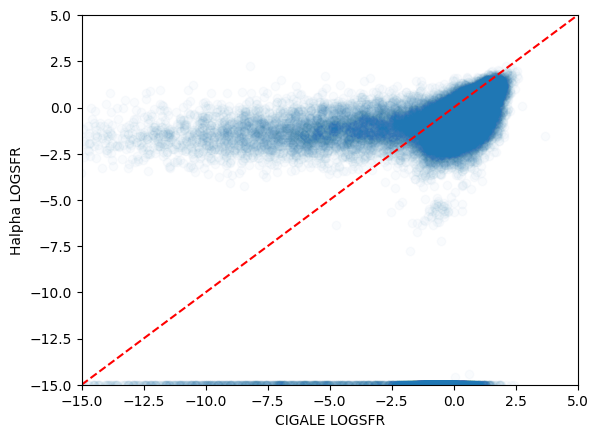

In [8]:
x = np.linspace(-15, 5, 100)
plt.scatter(all_df['LOGSFR'], all_df['LOGSFR_1COMP'], alpha=0.025)
plt.plot(x, x, color='red', linestyle='--')
plt.ylim((-15, 5))
plt.xlim((-15, 5))
plt.xlabel('CIGALE LOGSFR')
plt.ylabel('Halpha LOGSFR')

plt.show()

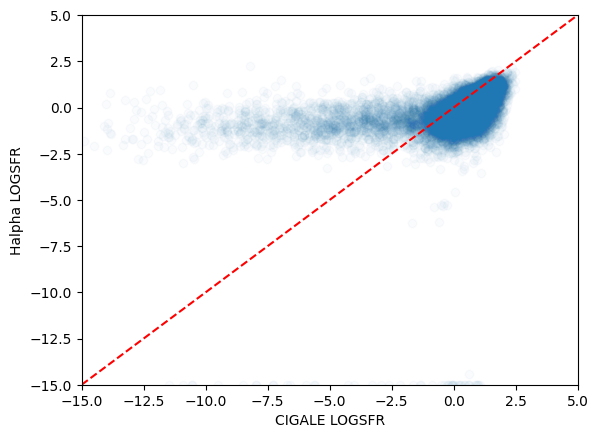

In [9]:
x = np.linspace(-15, 5, 100)
plt.scatter(dps_df['LOGSFR'], dps_df['LOGSFR_1COMP'], alpha=0.025)
plt.plot(x, x, color='red', linestyle='--')
plt.ylim((-15, 5))
plt.xlim((-15, 5))
plt.xlabel('CIGALE LOGSFR')
plt.ylabel('Halpha LOGSFR')
plt.show()

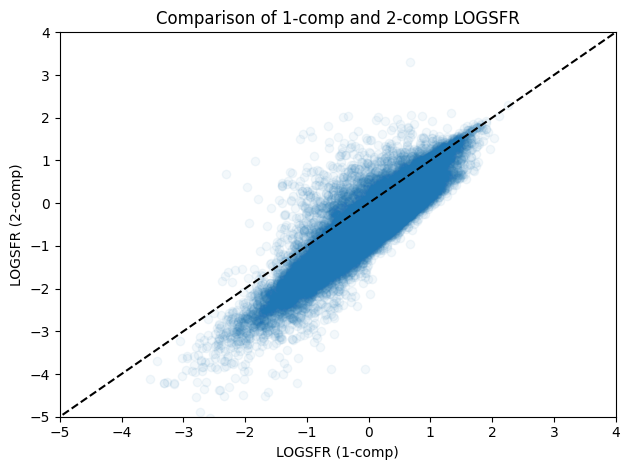

In [10]:
x = np.linspace(-15, 5, 100)
plt.scatter(dps_df['LOGSFR_1COMP'], dps_df['LOGSFR_2COMP'], alpha=0.05)
plt.plot(x, x, color='k', linestyle='--')
plt.ylim((-5, 4))
plt.xlim((-5, 4))
plt.xlabel('LOGSFR (1-comp)')
plt.ylabel('LOGSFR (2-comp)')
plt.title('Comparison of 1-comp and 2-comp LOGSFR')
plt.tight_layout()
plt.savefig('./figures/Mar26/SFR_compare_comp.png')
plt.show()

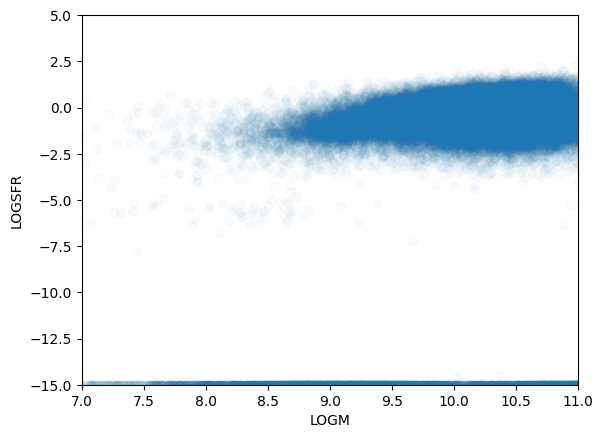

In [11]:
plt.scatter(all_df['LOGM'], all_df['LOGSFR_1COMP'], alpha=0.025)
plt.ylim((-15, 5))
plt.xlim((7, 11))
plt.xlabel('LOGM')
plt.ylabel('LOGSFR')
plt.show()

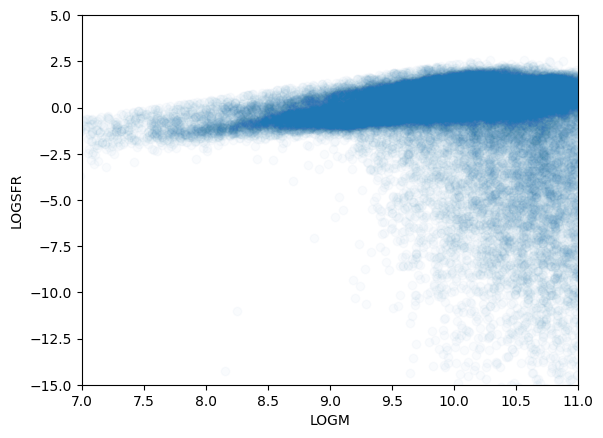

In [12]:
plt.scatter(all_df['LOGM'], all_df['LOGSFR'], alpha=0.025)
plt.ylim((-15, 5))
plt.xlim((7, 11))
plt.xlabel('LOGM')
plt.ylabel('LOGSFR')
plt.show()

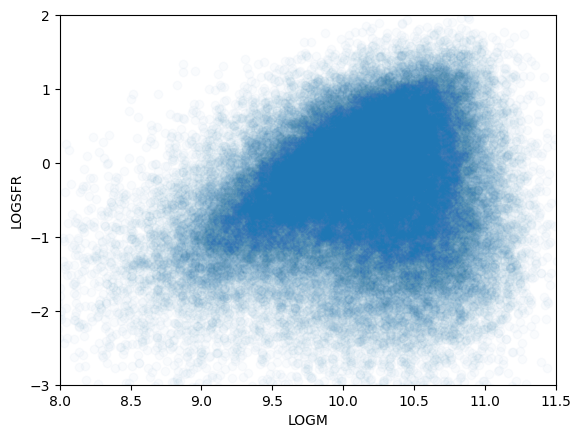

In [13]:
plt.scatter(all_df['LOGM'], all_df['LOGSFR_1COMP'], alpha=0.025)
plt.ylim((-3, 2))
plt.xlim((8, 11.5))
plt.xlabel('LOGM')
plt.ylabel('LOGSFR')

plt.show()

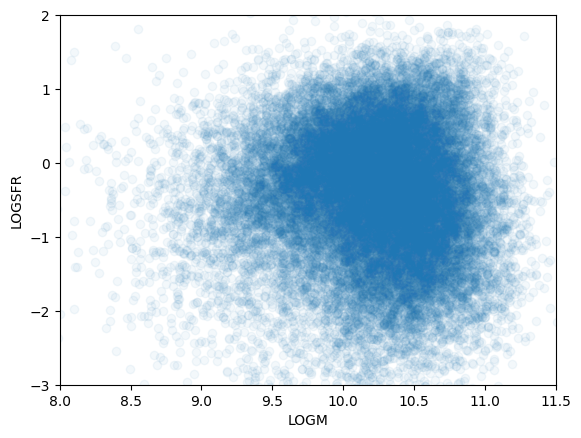

In [14]:
plt.scatter(dps_df['LOGM'], dps_df['LOGSFR_2COMP'], alpha=0.05)
plt.ylim((-3, 2))
plt.xlim((8, 11.5))
plt.xlabel('LOGM')
plt.ylabel('LOGSFR')

plt.show()

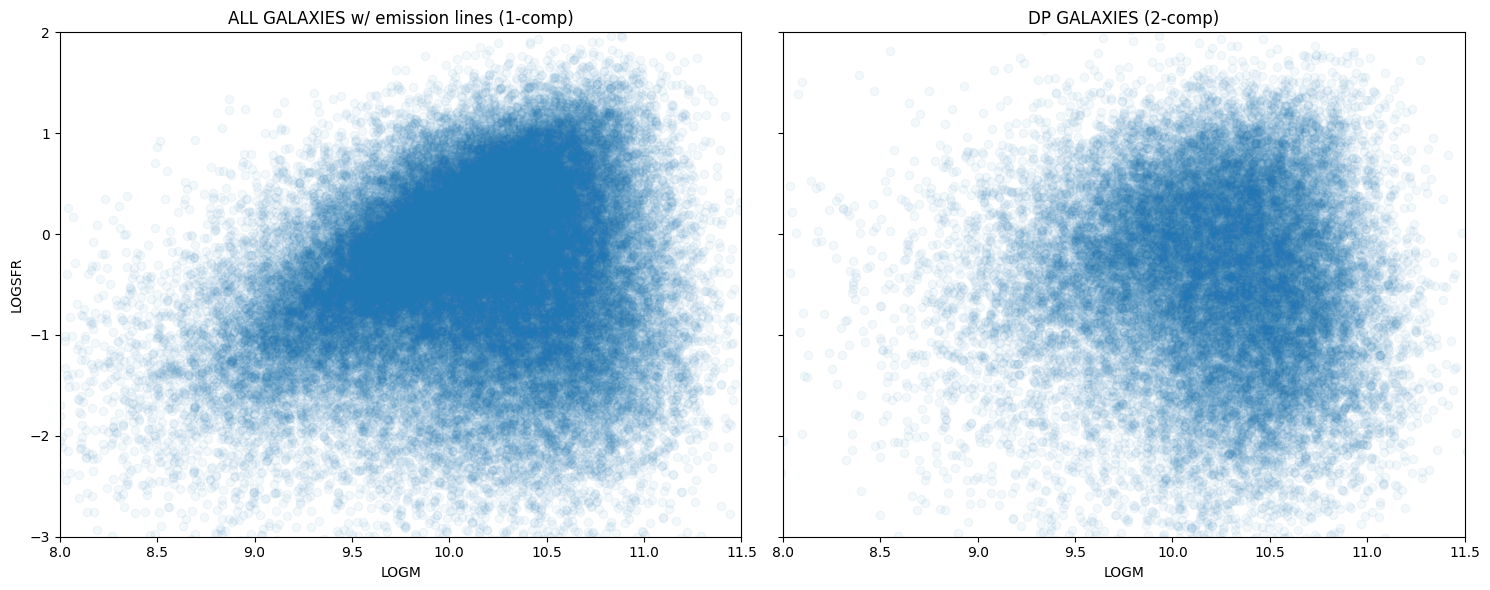

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.0)

x = np.linspace(8, 12, 100)
y = -9 + 0.9 * x

ax[0].scatter(all_df['LOGM'], all_df['LOGSFR_1COMP'], alpha=0.05)
ax[0].set_ylim((-3, 2))
ax[0].set_xlim((8, 11.5))
ax[0].set_xlabel('LOGM')
ax[0].set_ylabel('LOGSFR')
ax[0].set_title('ALL GALAXIES w/ emission lines (1-comp)')

ax[1].scatter(dps_df['LOGM'], dps_df['LOGSFR_2COMP'], alpha=0.05)
ax[1].set_ylim((-3, 2))
ax[1].set_xlim((8, 11.5))
ax[1].set_xlabel('LOGM')
# ax[1].set_ylabel('LOGSFR')
ax[1].set_title('DP GALAXIES (2-comp)')
plt.tight_layout()
plt.savefig('./figures/Mar26/M_SFR_halpha.png')
plt.show()

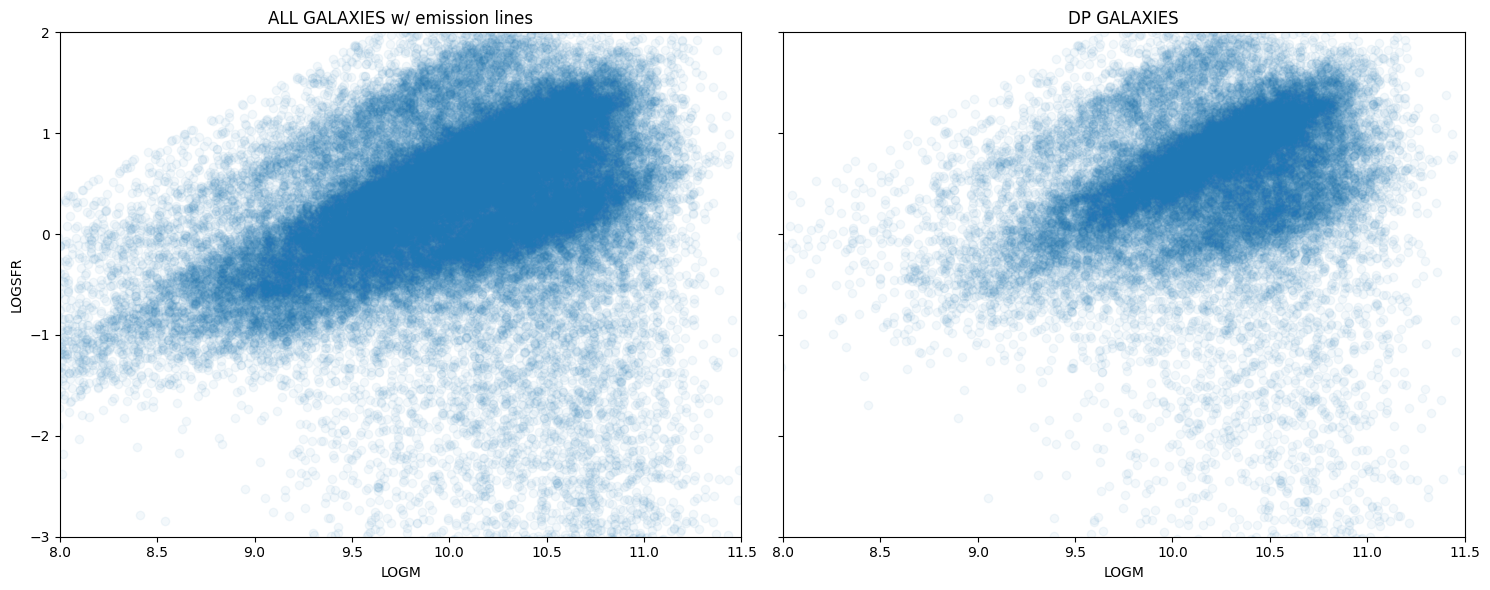

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.0)

x = np.linspace(8, 12, 100)
y = -9 + 0.9 * x

ax[0].scatter(all_df['LOGM'], all_df['LOGSFR'], alpha=0.05)
ax[0].set_ylim((-3, 2))
ax[0].set_xlim((8, 11.5))
ax[0].set_xlabel('LOGM')
ax[0].set_ylabel('LOGSFR')
ax[0].set_title('ALL GALAXIES w/ emission lines')

ax[1].scatter(dps_df['LOGM'], dps_df['LOGSFR'], alpha=0.05)
ax[1].set_ylim((-3, 2))
ax[1].set_xlim((8, 11.5))
ax[1].set_xlabel('LOGM')
# ax[1].set_ylabel('LOGSFR')
ax[1].set_title('DP GALAXIES')
plt.tight_layout()
plt.savefig('./figures/Mar26/M_SFR_cigale.png')
plt.show()

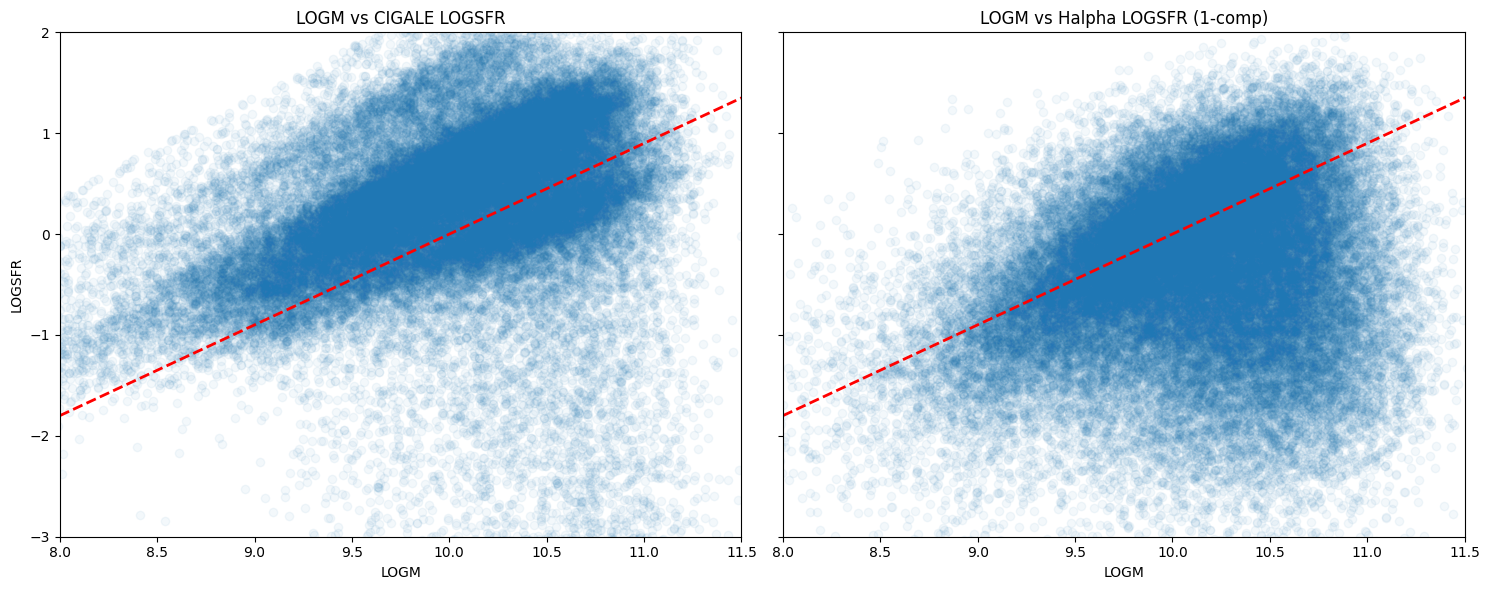

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.0)

x = np.linspace(8, 12, 100)
y = -9 + 0.9 * x

ax[0].scatter(all_df['LOGM'], all_df['LOGSFR'], alpha=0.05)
ax[0].plot(x, y, color='red', linestyle='--', linewidth=2)
ax[0].set_ylim((-3, 2))
ax[0].set_xlim((8, 11.5))
ax[0].set_xlabel('LOGM')
ax[0].set_ylabel('LOGSFR')
ax[0].set_title('LOGM vs CIGALE LOGSFR')

ax[1].scatter(all_df['LOGM'], all_df['LOGSFR_1COMP'], alpha=0.05)
ax[1].plot(x, y, color='red', linestyle='--', linewidth=2)
ax[1].set_ylim((-3, 2))
ax[1].set_xlim((8, 11.5))
ax[1].set_xlabel('LOGM')
# ax[1].set_ylabel('LOGSFR')
ax[1].set_title('LOGM vs Halpha LOGSFR (1-comp)')
plt.tight_layout()
plt.savefig('./figures/Mar26/SFR_compare_all.png')
plt.show()

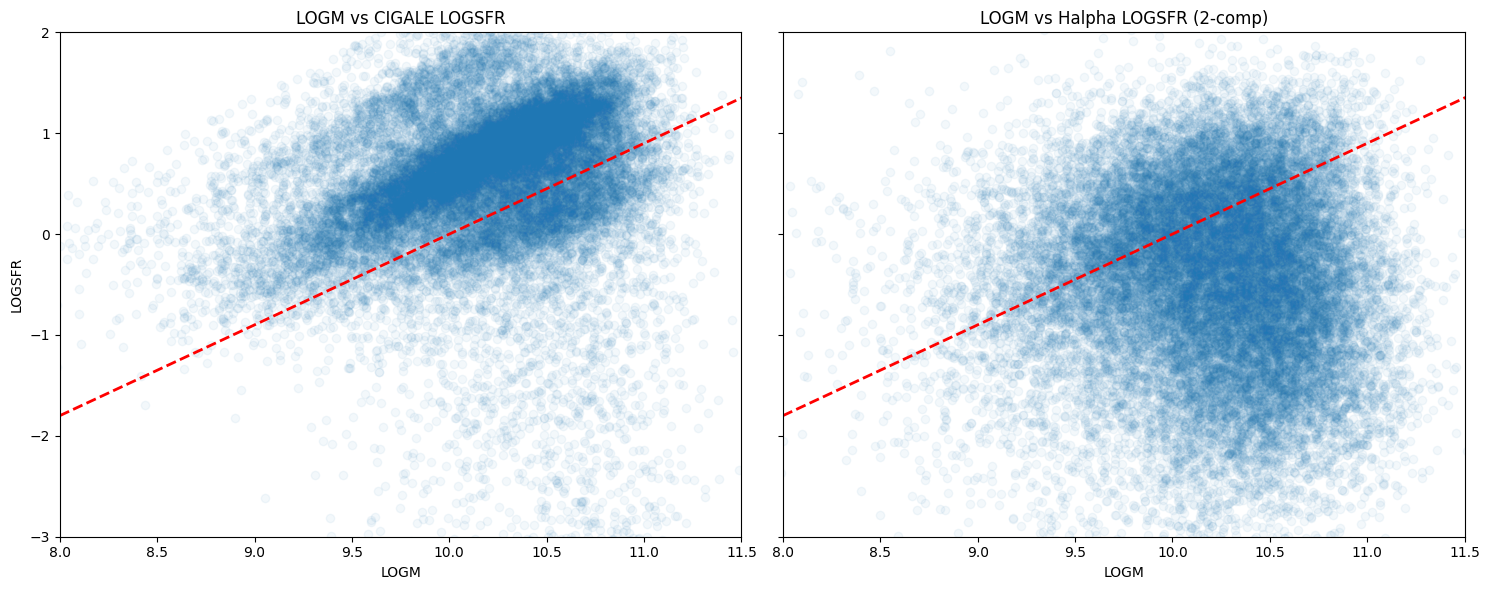

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.0)

x = np.linspace(8, 12, 100)
y = -9 + 0.9 * x

ax[0].scatter(dps_df['LOGM'], dps_df['LOGSFR'], alpha=0.05)
ax[0].plot(x, y, color='red', linestyle='--', linewidth=2)
ax[0].set_ylim((-3, 2))
ax[0].set_xlim((8, 11.5))
ax[0].set_xlabel('LOGM')
ax[0].set_ylabel('LOGSFR')
ax[0].set_title('LOGM vs CIGALE LOGSFR')

ax[1].scatter(dps_df['LOGM'], dps_df['LOGSFR_2COMP'], alpha=0.05)
ax[1].plot(x, y, color='red', linestyle='--', linewidth=2)
ax[1].set_ylim((-3, 2))
ax[1].set_xlim((8, 11.5))
ax[1].set_xlabel('LOGM')
# ax[1].set_ylabel('LOGSFR')
ax[1].set_title('LOGM vs Halpha LOGSFR (2-comp)')
plt.tight_layout()
plt.savefig('./figures/Mar26/SFR_compare_dps.png')
plt.show()

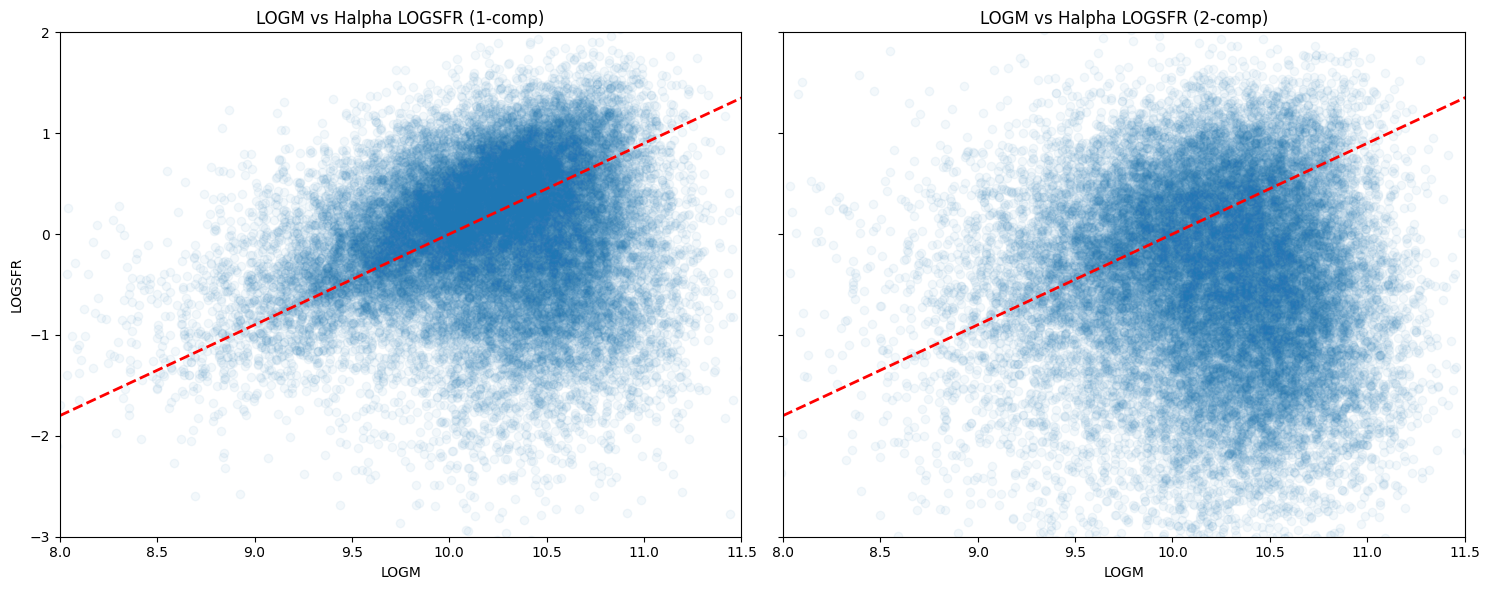

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.0)

x = np.linspace(8, 12, 100)
y = -9 + 0.9 * x

ax[0].scatter(dps_df['LOGM'], dps_df['LOGSFR_1COMP'], alpha=0.05)
ax[0].plot(x, y, color='red', linestyle='--', linewidth=2)
ax[0].set_ylim((-3, 2))
ax[0].set_xlim((8, 11.5))
ax[0].set_xlabel('LOGM')
ax[0].set_ylabel('LOGSFR')
ax[0].set_title('LOGM vs Halpha LOGSFR (1-comp)')

ax[1].scatter(dps_df['LOGM'], dps_df['LOGSFR_2COMP'], alpha=0.05)
ax[1].plot(x, y, color='red', linestyle='--', linewidth=2)
ax[1].set_ylim((-3, 2))
ax[1].set_xlim((8, 11.5))
ax[1].set_xlabel('LOGM')
# ax[1].set_ylabel('LOGSFR')
ax[1].set_title('LOGM vs Halpha LOGSFR (2-comp)')
plt.tight_layout()
plt.savefig('./figures/Mar26/SFR_compare_dps_12comp.png')
plt.show()

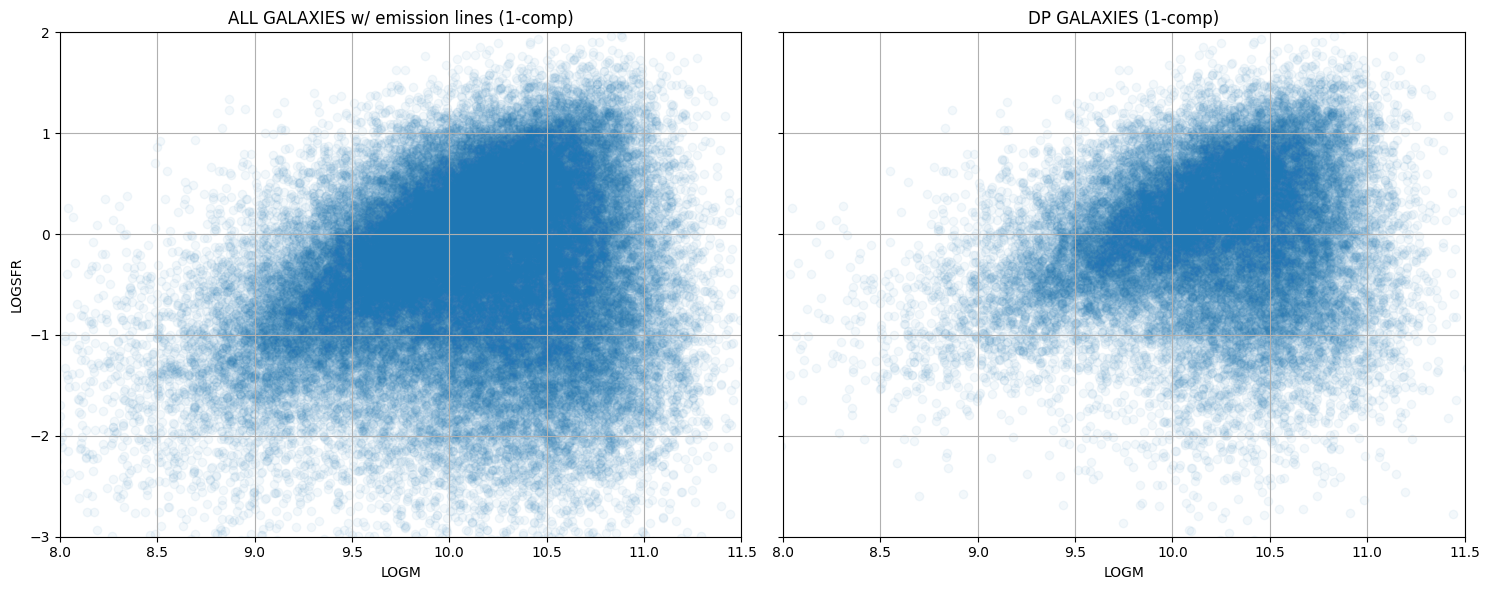

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.0)


ax[0].scatter(all_df['LOGM'], all_df['LOGSFR_1COMP'], alpha=0.05)
ax[0].set_ylim((-3, 2))
ax[0].set_xlim((8, 11.5))
ax[0].set_xlabel('LOGM')
ax[0].set_ylabel('LOGSFR')
ax[0].set_title('ALL GALAXIES w/ emission lines (1-comp)')
ax[0].grid()

ax[1].scatter(dps_df['LOGM'], dps_df['LOGSFR_1COMP'], alpha=0.05)
ax[1].set_ylim((-3, 2))
ax[1].set_xlim((8, 11.5))
ax[1].set_xlabel('LOGM')
ax[1].set_title('DP GALAXIES (1-comp)')
ax[1].grid()
plt.tight_layout()
plt.savefig('./figures/Mar26/M_SFR_bin.png')
plt.show()

In [21]:
logm_bins_bound = np.arange(8, 12, 0.5)
logsfr_bins_bound = np.arange(-3, 3, 1)

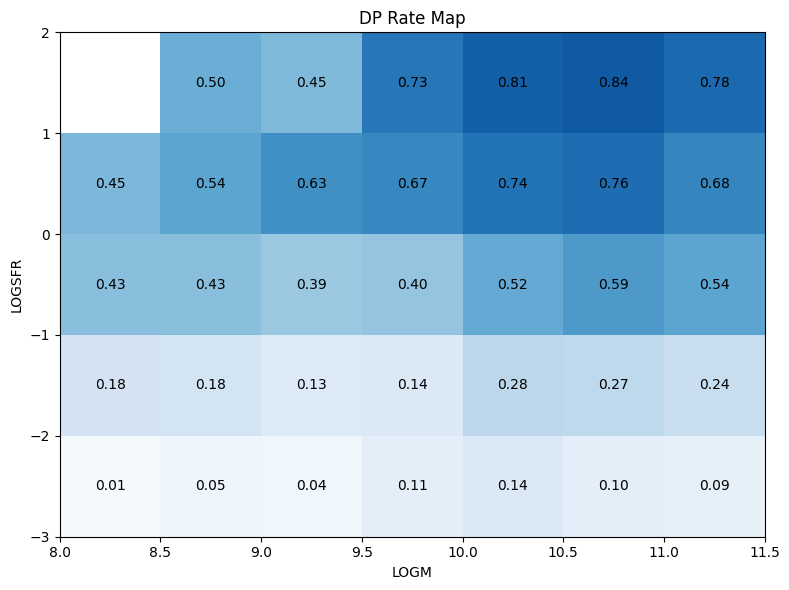

In [22]:
H_all, _, _ = np.histogram2d(all_df['LOGM'], all_df['LOGSFR_1COMP'], bins=[logm_bins_bound, logsfr_bins_bound])
H_dps, _, _ = np.histogram2d(dps_df['LOGM'], dps_df['LOGSFR_1COMP'], bins=[logm_bins_bound, logsfr_bins_bound])

# Avoid division by zero by replacing zeros in H_all with NaNs
with np.errstate(divide='ignore', invalid='ignore'):
    dp_rate_map = H_dps / H_all

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Use pcolormesh to plot the DP rate map
# Note: The histogram arrays need to be transposed for pcolormesh to match the axes
mesh = ax.pcolormesh(logm_bins_bound, logsfr_bins_bound, dp_rate_map.T, cmap='Blues', vmin=0, vmax=1)

# Add text annotations for the rate in each bin
for i in range(len(logm_bins_bound) - 1):
    for j in range(len(logsfr_bins_bound) - 1):
        rate = dp_rate_map[i, j]
        if not np.isnan(rate):
            x_center = (logm_bins_bound[i] + logm_bins_bound[i+1]) / 2
            y_center = (logsfr_bins_bound[j] + logsfr_bins_bound[j+1]) / 2
            ax.text(x_center, y_center, f'{rate:.2f}', 
                    ha='center', va='center', color='black', fontsize=10)

ax.set_xlabel('LOGM')
ax.set_ylabel('LOGSFR')
ax.set_title('DP Rate Map')
# fig.colorbar(mesh, ax=ax, label='DP Rate')
plt.tight_layout()
plt.savefig('./figures/Mar26/DP_rate_map.png')
plt.show()

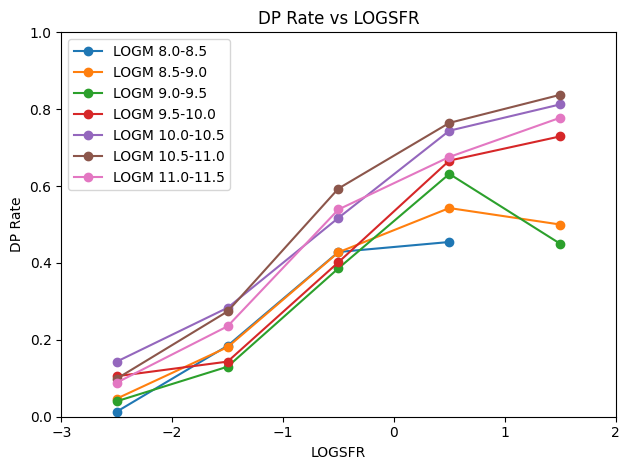

In [23]:
for i in range(len(logm_bins_bound) - 1):
    plt.plot(logsfr_bins_bound[:-1]+0.5, dp_rate_map[i, :], label=f'LOGM {logm_bins_bound[i]}-{logm_bins_bound[i+1]}', marker='o')
plt.xlim(-3, 2)
plt.ylim(0, 1)
plt.xlabel('LOGSFR')
plt.ylabel('DP Rate')
plt.title('DP Rate vs LOGSFR')
plt.legend()
plt.tight_layout()
plt.savefig('./figures/Mar26/DP_rate_vs_logsfr.png')
plt.show()

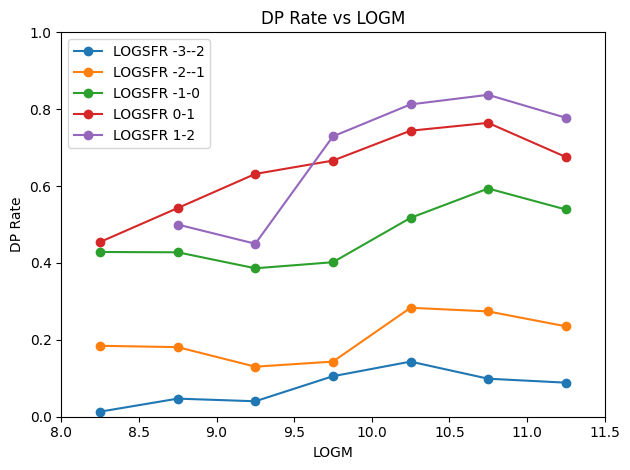

In [24]:
for i in range(len(logsfr_bins_bound) - 1):
    plt.plot(logm_bins_bound[:-1]+0.25, dp_rate_map[:, i], label=f'LOGSFR {logsfr_bins_bound[i]}-{logsfr_bins_bound[i+1]}', marker='o')
plt.xlim(8, 11.5)
plt.ylim(0, 1)
plt.xlabel('LOGM')
plt.ylabel('DP Rate')
plt.title('DP Rate vs LOGM')
plt.legend()
plt.tight_layout()
plt.savefig('./figures/Mar26/DP_rate_vs_logm.png')


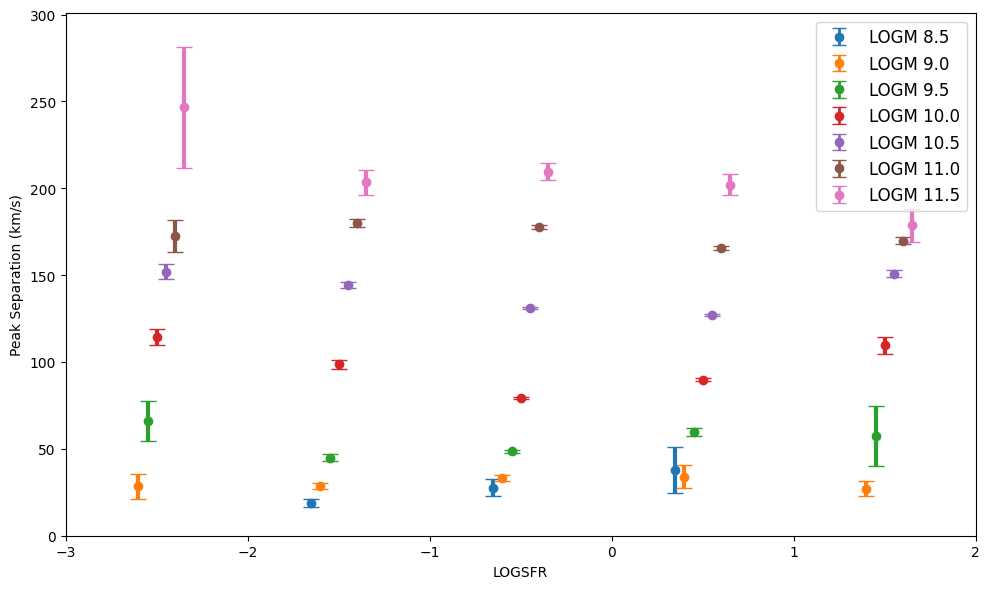

In [37]:
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
offsets = np.linspace(-0.15, 0.15, len(logm_bins_bound)-1)
plt.figure(figsize=(10, 6))
for i in range(len(logm_bins_bound) - 1):
    plt.errorbar(-1, -100, yerr=0, color=colors[i], fmt='o', capsize=5, ecolor=colors[i], elinewidth=2, label=f'LOGM {logm_bins_bound[i]+0.5}')
    for j in range(len(logsfr_bins_bound) - 1):
        sub_df = dps_df[(dps_df['LOGM'] >= logm_bins_bound[i]) & (dps_df['LOGM'] < logm_bins_bound[i+1]) & (dps_df['LOGSFR_1COMP'] >= logsfr_bins_bound[j]) & (dps_df['LOGSFR_1COMP'] < logsfr_bins_bound[j+1])]
        if len(sub_df) > 1:
            delta_v = np.array(sub_df['DV_R']-sub_df['DV_L'])
            # plt.scatter([logsfr_bins_bound[j]+0.5]*len(delta_v), delta_v, alpha=0.05)
            res = bootstrap((delta_v,), np.mean, confidence_level=0.95, n_resamples=1000)
            plt.errorbar(x=logsfr_bins_bound[j]+0.5+offsets[i], y=np.mean(delta_v), yerr=res.standard_error, color=colors[i], fmt='o', capsize=6, ecolor=colors[i], elinewidth=3)
plt.xlabel('LOGSFR')
plt.ylabel('Peak Separation (km/s)')
plt.legend(fontsize=12)
plt.ylim(bottom=0)
plt.xlim(logsfr_bins_bound[0], logsfr_bins_bound[-1])
plt.tight_layout()
plt.savefig('./figures/Mar26/deltav_logsfr.png')
plt.show()

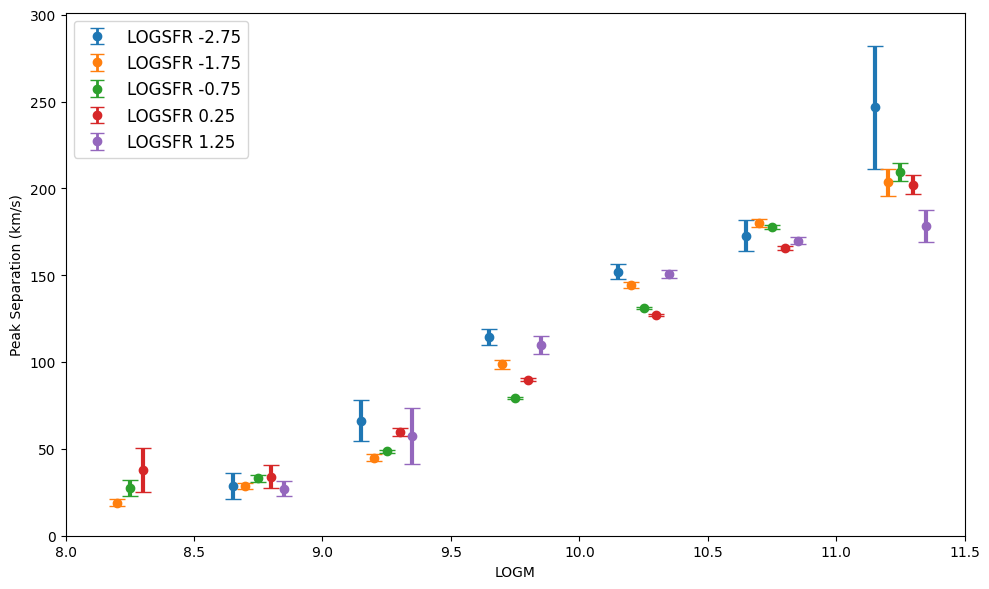

In [38]:
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
offsets = np.linspace(-0.1, 0.1, len(logsfr_bins_bound)-1)
plt.figure(figsize=(10, 6))
for i in range(len(logsfr_bins_bound) - 1):
    plt.errorbar(0, -100, yerr=0, color=colors[i], fmt='o', capsize=5, ecolor=colors[i], elinewidth=2, label=f'LOGSFR {logsfr_bins_bound[i]+0.25}')
    for j in range(len(logm_bins_bound) - 1):
        sub_df = dps_df[(dps_df['LOGM'] >= logm_bins_bound[j]) & (dps_df['LOGM'] < logm_bins_bound[j+1]) & (dps_df['LOGSFR_1COMP'] >= logsfr_bins_bound[i]) & (dps_df['LOGSFR_1COMP'] < logsfr_bins_bound[i+1])]
        if len(sub_df) > 1:
            delta_v = np.array(sub_df['DV_R']-sub_df['DV_L'])
            # plt.scatter([logsfr_bins_bound[j]+0.5]*len(delta_v), delta_v, alpha=0.05)
            res = bootstrap((delta_v,), np.mean, confidence_level=0.95, n_resamples=1000)
            plt.errorbar(x=logm_bins_bound[j]+0.25+offsets[i], y=np.mean(delta_v), yerr=res.standard_error, color=colors[i], fmt='o', capsize=6, ecolor=colors[i], elinewidth=3)
plt.xlabel('LOGM')
plt.ylabel('Peak Separation (km/s)')
plt.ylim(bottom=0)
plt.xlim(logm_bins_bound[0], logm_bins_bound[-1])
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('./figures/Mar26/deltav_logm.png')
plt.show()